In [2]:
import yfinance as yf

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

Fetching data for AAPL...


[*********************100%***********************]  1 of 1 completed
C:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Building the LSTM Model...
Training the model (this may take a minute)...
Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - loss: 0.0127
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0021
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0018
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 0.0014
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.0015
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.0012
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0012
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0011
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0013
Epoch 10/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.0010
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step
Model RMSE: 9.04


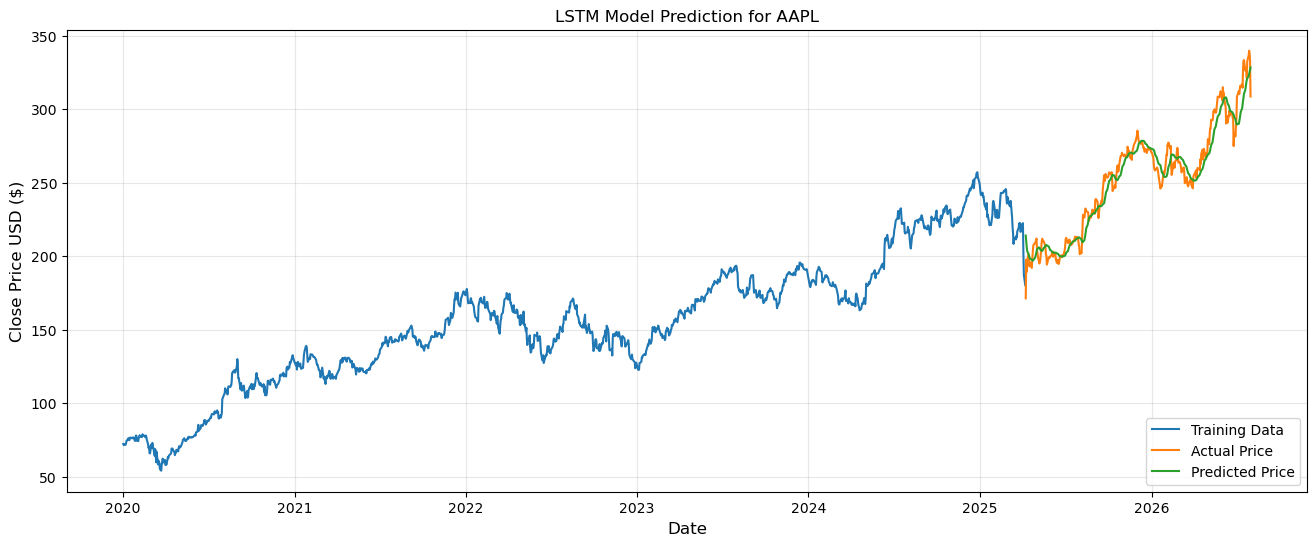

In [5]:
# 1. Data Collection

ticker = 'AAPL'
print(f"Fetching data for {ticker}...")

# Fetching data from 2020 to mid-2026
data = yf.download(ticker, start='2020-01-01', end='2026-08-01')

# We will only use the 'Close' price for this baseline model
df = data[['Close']].copy()


# 2. Data Preprocessing

# LSTMs are sensitive to the scale of the input data, so we normalize it between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df.values)

# Split data into training (80%) and testing (20%)
training_data_len = int(np.ceil(len(scaled_data) * .8))
train_data = scaled_data[0:int(training_data_len), :]

# Create the training sequences
# We will look back 60 days to predict the 61st day
sequence_length = 60
x_train, y_train = [], []

for i in range(sequence_length, len(train_data)):
    x_train.append(train_data[i-sequence_length:i, 0])
    y_train.append(train_data[i, 0])

# Convert to numpy arrays and reshape for LSTM [samples, time steps, features]
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))


# 3. Model Architecture

print("Building the LSTM Model...")
model = Sequential()

# First LSTM layer with Dropout regularization to prevent overfitting
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Output layer (Predicting a single continuous value)
model.add(Dense(units=25))
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')


# 4. Model Training

print("Training the model (this may take a minute)...")
# Epochs kept low (10) for quick testing. Increase to 20-50 for better accuracy.
model.fit(x_train, y_train, batch_size=32, epochs=10)


# 5. Testing & Evaluation

# Create the testing data set
test_data = scaled_data[training_data_len - sequence_length: , :]
x_test, y_test = [], df.values[training_data_len:, :]

for i in range(sequence_length, len(test_data)):
    x_test.append(test_data[i-sequence_length:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the models predicted price values
predictions = model.predict(x_test)
# Unscale the predictions back to real dollar values
predictions = scaler.inverse_transform(predictions)

# Calculate Root Mean Squared Error (RMSE) to evaluate performance
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
print(f"Model RMSE: {rmse:.2f}")


# 6. Visualization

train = df[:training_data_len]
valid = df[training_data_len:].copy()
valid['Predictions'] = predictions

plt.figure(figsize=(16, 6))
plt.title(f'LSTM Model Prediction for {ticker}')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price USD ($)', fontsize=12)
plt.plot(train['Close'], label='Training Data')
plt.plot(valid['Close'], label='Actual Price')
plt.plot(valid['Predictions'], label='Predicted Price')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# Define the stock ticker and the date range

ticker = 'AAPL'
start_date = '2020-01-01'
end_date = '2026-08-15'

print(f"Fetching data for {ticker}...")

# Download the data from Yahoo Finance
data = yf.download(ticker, start=start_date, end=end_date)

# Display the first 5 rows of our dataset
print(data.head())
print(data.tail())

Fetching data for AAPL...


[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.271545  72.331702  71.029923  71.282575  135480400
2020-01-03  71.568924  72.326889  71.345145  71.501549  146322800
2020-01-06  72.139183  72.177684  70.442784  70.693036  118387200
2020-01-07  71.799927  72.403889  71.580958  72.148828  108872000
2020-01-08  72.954910  73.255691  71.503945  71.503945  132079200
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2026-08-10  308.260010  308.260010  304.609985  306.829987  44812500
2026-08-11  304.910004  309.970001  302.790009  307.750000  37476700
2026-08-12  302.250000  305.660004  300.570007  305.100006  41657800
2026-08-13  305.260010  306.000000  302.049988  304.209991

In [7]:
# We will only use the 'Close' price for this model

df = data[['Close']].copy()

# 1. Scale the data between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df.values)

# 2. Figure out how many rows equals 80% of our data for training
training_data_len = int(np.ceil(len(scaled_data) * .8))
train_data = scaled_data[0:int(training_data_len), :]

# 3. Create the 60-day sequences
sequence_length = 60
x_train = []
y_train = []

for i in range(sequence_length, len(train_data)):
    # Grab the previous 60 days
    x_train.append(train_data[i-sequence_length:i, 0])
    # Grab the 61st day (the target we want to predict)
    y_train.append(train_data[i, 0])

# 4. Convert lists to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# 5. Reshape the data for the LSTM [number of samples, time steps, features]
# We have 1 feature (the Close price)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print("Data successfully preprocessed!")
print(f"x_train shape: {x_train.shape}")

Data successfully preprocessed!
x_train shape: (1271, 60, 1)


In [8]:
# 1. Initialize the Neural Network

model = Sequential()

# 2. Add the first LSTM layer and some Dropout regularization
# return_sequences=True is required because we are passing the output to another LSTM layer
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))

# 3. Add a second LSTM layer
# return_sequences=False because we are moving to the final output stages
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# 4. Add Dense (standard) layers to condense the output down to 1 single price prediction
model.add(Dense(units=25))
model.add(Dense(units=1))

# 5. Compile the model
# Adam is a highly efficient optimizer, and mean_squared_error is standard for regression
model.compile(optimizer='adam', loss='mean_squared_error')

print("Model compiled. Starting training...")

# 6. Train the model
# We will use 10 epochs (training cycles) for speed. You can increase this later.
model.fit(x_train, y_train, batch_size=32, epochs=10)

C:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model compiled. Starting training...
Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - loss: 0.0141
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0023
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0020
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0016
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0015
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0017
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0012
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0013
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0013
Epoch 10/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0011


Preparing test data and generating predictions...
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
Model RMSE: 10.23
Plotting the results...


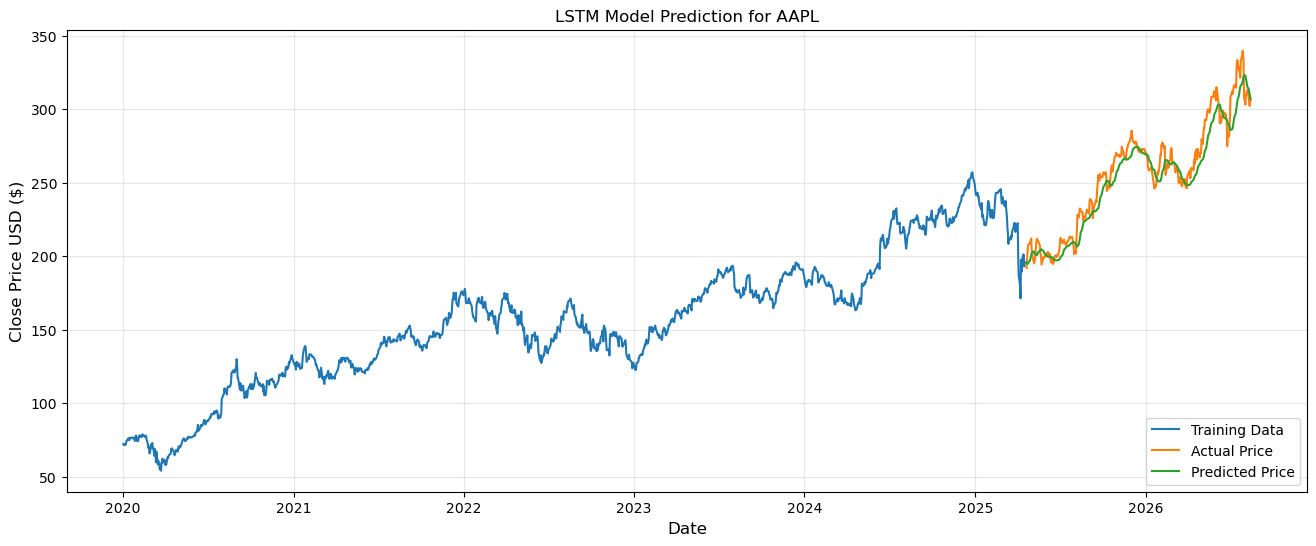

In [9]:
# 5. Testing & Evaluation

print("Preparing test data and generating predictions...")

# Create the testing data set
# We need to start 60 days before the test set begins so we have the sequence context
test_data = scaled_data[training_data_len - sequence_length: , :]

# The true actual prices (for comparison later)
y_test = df.values[training_data_len:, :]
x_test = []

for i in range(sequence_length, len(test_data)):
    x_test.append(test_data[i-sequence_length:i, 0])

# Convert to numpy array and reshape
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the model's predicted price values
predictions = model.predict(x_test)

# IMPORTANT: The model predicts scaled numbers between 0 and 1. 
# We must reverse this scaling to get actual Dollar ($) amounts back.
predictions = scaler.inverse_transform(predictions)

# Calculate Root Mean Squared Error (RMSE) to evaluate accuracy
# A lower RMSE is better!
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
print(f"Model RMSE: {rmse:.2f}")

# ==========================================
# 6. Visualization
# ==========================================
print("Plotting the results...")

# Split the original dataframe to plot training vs testing sections
train = df[:training_data_len]
valid = df[training_data_len:].copy()

# Add our predictions to the validation dataframe
valid['Predictions'] = predictions

# Set up the plot
plt.figure(figsize=(16, 6))
plt.title(f'LSTM Model Prediction for {ticker}')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price USD ($)', fontsize=12)

# Plot the training data, actual test data, and our predictions
plt.plot(train['Close'], label='Training Data')
plt.plot(valid['Close'], label='Actual Price')
plt.plot(valid['Predictions'], label='Predicted Price')

plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Grab the very last 60 days of closing prices from our original dataframe
last_60_days = df[-60:].values

# Scale the data using the exact same scaler we fitted earlier
last_60_days_scaled = scaler.transform(last_60_days)

# Create an empty list and append the past 60 days
X_test_future = []
X_test_future.append(last_60_days_scaled)

# Convert to numpy array and reshape it to [1, 60, 1] so the LSTM can read it
X_test_future = np.array(X_test_future)
X_test_future = np.reshape(X_test_future, (X_test_future.shape[0], X_test_future.shape[1], 1))

# Predict the scaled price
pred_price = model.predict(X_test_future)

# Unscale the price back to USD
pred_price_usd = scaler.inverse_transform(pred_price)

print(f"Predicted Price for the Next Trading Day: ${pred_price_usd[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted Price for the Next Trading Day: $305.59


In [11]:
# 1. Calculate the 50-Day Simple Moving Average (SMA)

df['SMA_50'] = df['Close'].rolling(window=50).mean()

# 2. Calculate the 14-Day Relative Strength Index (RSI)
# First, get the daily price changes
delta = df['Close'].diff(1)
delta = delta.dropna()

# Separate the gains and losses
gains = delta.where(delta > 0, 0)
losses = -delta.where(delta < 0, 0)

# Calculate the rolling average of gains and losses over 14 days
avg_gain = gains.rolling(window=14).mean()
avg_loss = losses.rolling(window=14).mean()

# Calculate the Relative Strength (RS) and then the RSI
rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# 3. Drop the empty rows created by the rolling windows
df = df.dropna()

print("Technical indicators successfully added!")
print(df.tail())

Technical indicators successfully added!
Price            Close      SMA_50     RSI_14
Ticker            AAPL                       
Date                                         
2026-08-10  308.260010  309.438845  37.338130
2026-08-11  304.910004  309.301223  36.612902
2026-08-12  302.250000  309.225302  37.370038
2026-08-13  305.260010  309.031934  29.620534
2026-08-14  305.929993  308.950681  26.093530


In [12]:
# 1. Scale all 3 features together

feature_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_features = feature_scaler.fit_transform(df[['Close', 'SMA_50', 'RSI_14']].values)

# Dedicated scaler just for Close price (makes converting predictions back to USD simple)
target_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_target = target_scaler.fit_transform(df[['Close']].values)

# 2. Train/Test Split (80% / 20%)
training_len = int(np.ceil(len(scaled_features) * 0.8))
train_feat = scaled_features[:training_len]
train_tgt = scaled_target[:training_len]

# 3. Create 60-day sequences with 3 features
seq_len = 60
x_train_multi, y_train_multi = [], []

for i in range(seq_len, len(train_feat)):
    x_train_multi.append(train_feat[i-seq_len:i, :])   # all 3 features for past 60 days
    y_train_multi.append(train_tgt[i, 0])              # predicting day 61's Close price

x_train_multi = np.array(x_train_multi)
y_train_multi = np.array(y_train_multi)

print(f"Multi-feature x_train shape: {x_train_multi.shape}")  # Should be (N, 60, 3)

# 4. Build the Multi-Feature LSTM Model
multi_model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(seq_len, 3)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

multi_model.compile(optimizer='adam', loss='mean_squared_error')

print("Training multi-feature model...")
multi_model.fit(x_train_multi, y_train_multi, batch_size=32, epochs=10)
print("Training complete!")

Multi-feature x_train shape: (1232, 60, 3)
Training multi-feature model...
Epoch 1/10


C:\Users\ADMIN\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - loss: 0.0168
Epoch 2/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0029
Epoch 3/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0024
Epoch 4/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0019
Epoch 5/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0017
Epoch 6/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0017
Epoch 7/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0016
Epoch 8/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0014
Epoch 9/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0013
Epoch 10/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0012
Training complete!


In [13]:
# 1. Prepare testing sequences with all 3 features

test_feat = scaled_features[training_len - seq_len:, :]
y_test_actual = df[['Close']].values[training_len:]
x_test_multi = []

for i in range(seq_len, len(test_feat)):
    x_test_multi.append(test_feat[i-seq_len:i, :])

x_test_multi = np.array(x_test_multi)

# 2. Predict on the test set and reverse scaling back to USD
predictions_multi = multi_model.predict(x_test_multi)
predictions_multi = target_scaler.inverse_transform(predictions_multi)

# 3. Calculate RMSE
rmse_multi = np.sqrt(np.mean(((predictions_multi - y_test_actual) ** 2)))
print(f"Multi-Feature Model RMSE: {rmse_multi:.2f}")

# 4. Predict the next trading day using the latest 60 days of data
last_60_multi = scaled_features[-60:]
x_future_multi = np.array([last_60_multi])  # Shape: (1, 60, 3)

pred_next_day = multi_model.predict(x_future_multi)
pred_next_day_usd = target_scaler.inverse_transform(pred_next_day)

print(f"Multi-Feature Predicted Price for Next Trading Day: ${pred_next_day_usd[0][0]:.2f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
Multi-Feature Model RMSE: 8.60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Multi-Feature Predicted Price for Next Trading Day: $313.16
